In [2]:
import pandas as pd
from sklearn.cluster import MiniBatchKMeans

df = pd.read_csv('combined.csv')

In [3]:
import pandas as pd
import numpy as np

print(df.dtypes)

AMT_ANNUITY                  float64
AMT_CREDIT                   float64
AMT_GOODS_PRICE              float64
AMT_INCOME_TOTAL             float64
AMT_REQ_CREDIT_BUREAU_DAY    float64
                              ...   
prev_status_refused          float64
prev_status_unused offer     float64
prev_problem_applications    float64
prev_approved_rate           float64
prev_refused_rate            float64
Length: 230, dtype: object


In [4]:
df.dtypes.value_counts()

float64    174
int64       40
object      16
Name: count, dtype: int64

In [5]:
import pandas as pd

df = pd.read_csv('combined.csv')
df_result = df.copy()
threshold = 0.1

for col in df.columns:
    value_counts = df[col].value_counts(normalize=True)
    valid_categories = value_counts[value_counts >= threshold].index
    total_categories = len(value_counts)

    # 所有欄位都檢查二元比例過低的情況
    if total_categories == 2 and len(valid_categories) < 2:
        df_result = df_result.drop(columns=[col])
        continue

    if df[col].dtype == 'object':
        if len(valid_categories) > 0:
            dummies = pd.get_dummies(df[col], dummy_na=False)
            valid_existing = [c for c in valid_categories if c in dummies.columns]
            if valid_existing:
                dummies = dummies[valid_existing]
                dummies.columns = [f"{col}_{c}" for c in dummies.columns]
                df_result = pd.concat([df_result, dummies], axis=1)

        df_result = df_result.drop(columns=[col])

print(df_result.head())

   AMT_ANNUITY  AMT_CREDIT  AMT_GOODS_PRICE  AMT_INCOME_TOTAL  \
0      24700.5    406597.5         351000.0          202500.0   
1      35698.5   1293502.5        1129500.0          270000.0   
2       6750.0    135000.0         135000.0           67500.0   
3      29686.5    312682.5         297000.0          135000.0   
4      21865.5    513000.0         513000.0          121500.0   

   AMT_REQ_CREDIT_BUREAU_DAY  AMT_REQ_CREDIT_BUREAU_HOUR  \
0                        0.0                         0.0   
1                        0.0                         0.0   
2                        0.0                         0.0   
3                        NaN                         NaN   
4                        0.0                         0.0   

   AMT_REQ_CREDIT_BUREAU_MON  AMT_REQ_CREDIT_BUREAU_QRT  \
0                        0.0                        0.0   
1                        0.0                        0.0   
2                        0.0                        0.0   
3           

In [6]:
df_result = df_result.astype(float)
df_normalized = (df_result - df_result.min()) / (df_result.max() - df_result.min())
df_result = df_result.fillna(df_result.mean(numeric_only=True))
df_result.isna().sum().sum() 

0

C:\Users\487oa\AppData\Local\Temp\ipykernel_40980\62517185.py:10: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance, method='ward')


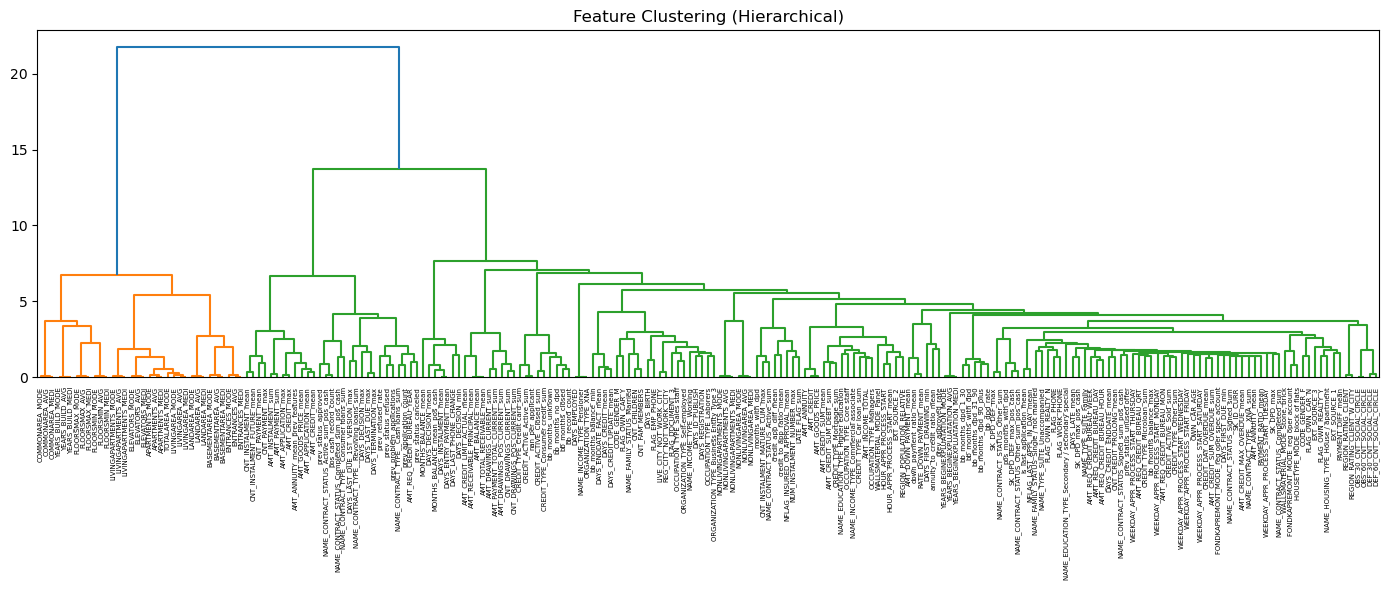

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# 計算特徵間距離（用 1 - correlation）
corr = df_result.corr().values 
distance = 1 - corr 

# 階層式叢集，用ward或average
linkage_matrix = linkage(distance, method='ward') 

# 畫 dendrogram 看特徵之間的距離
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=df_result.columns, leaf_rotation=90)
plt.title('Feature Clustering (Hierarchical)')
plt.tight_layout()
plt.show() 

In [ ]:
from scipy.cluster.hierarchy import fcluster 

# 分群 
cluster_labels = fcluster(linkage_matrix, t=6, criterion='distance') 

# 對應到欄位 
feature_clusters = pd.DataFrame({'feature': df_result.columns, 'cluster': cluster_labels}) 
print(feature_clusters.sort_values('cluster')) 

                                 feature  cluster
78                      YEARS_BUILD_MODE        1
19                       COMMONAREA_MEDI        1
20                       COMMONAREA_MODE        1
46                        FLOORSMIN_MODE        1
45                        FLOORSMIN_MEDI        1
..                                   ...      ...
93              CREDIT_TYPE_Car loan_sum        9
96             CREDIT_TYPE_Microloan_sum        9
97              CREDIT_TYPE_Mortgage_sum        9
86               CREDIT_DAY_OVERDUE_mean        9
220  WEEKDAY_APPR_PROCESS_START_SATURDAY        9

[221 rows x 2 columns]


In [34]:
print(feature_clusters['cluster'].value_counts().sort_index()) 

cluster
1     12
2     22
3     12
4     17
5      7
6      9
7      9
8      3
9    130
Name: count, dtype: int64


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def optimal_k_silhouette(feature_group_df, k_min=2, k_max=6):
    X = feature_group_df.values.T  # 每個 feature 是一個 sample

    n_samples = X.shape[0]
    if n_samples <= 2:
        return {"best_K": 1, "reason": "not enough features"}

    # 最大 K 限制不能超過 n_samples - 1
    max_K = min(k_max, n_samples - 1)
    Ks = list(range(k_min, max_K + 1))

    sil_scores = []

    for k in Ks:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
        labels = km.labels_
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

    # 找 silhouette 最佳 K
    best_k = Ks[np.argmax(sil_scores)]

    return {
        "Ks": Ks,
        "silhouette": sil_scores,
        "best_K": best_k
    }


In [46]:
optimal_K_per_group = {}

for c in sorted(feature_clusters['cluster'].unique()):
    features = feature_clusters[feature_clusters['cluster'] == c]['feature']
    group_df = df_result[features]

    eval_dict = optimal_k_silhouette(group_df, k_min=2, k_max=6)
    optimal_K_per_group[c] = eval_dict

c:\Users\487oa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\487oa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\487oa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\487oa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

In [47]:
optimal_K_per_group 

{1: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.8344470388322333,
   0.8452924214722363,
   0.912603859719347,
   0.7883106537559145,
   0.6660809359409565],
  'best_K': 4},
 2: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.2716672487128347,
   0.3652678149372315,
   0.4360353599266814,
   0.5187615584796955,
   0.684426730557674],
  'best_K': 6},
 3: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.7291086473538478,
   0.6308069175639611,
   0.8369721465004196,
   0.7092628523175578,
   0.5819067664344758],
  'best_K': 4},
 4: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.8776147737262068,
   0.8944381485541596,
   0.8230383027692101,
   0.7519620811318067,
   0.691770881595232],
  'best_K': 3},
 5: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.5983552566015072,
   0.5155211044059839,
   0.5790794483060999,
   0.5510831940552545,
   0.2716962828397479],
  'best_K': 2},
 6: {'Ks': [2, 3, 4, 5, 6],
  'silhouette': [0.6068246182271303,
   0.45384343557482953,
   0.514187549871977,
   0.6858188424461291,

In [48]:
from sklearn.cluster import MiniBatchKMeans
if 'SK_ID_CURR' not in df.columns:
    raise KeyError("SK_ID_CURR not found in original dataframe; unable to export labels.")

cluster_labels_df = pd.DataFrame(index=df.index)
target_clusters = 4
random_state = 42

for cluster_id in sorted(feature_clusters['cluster'].unique()):
    target_clusters = optimal_K_per_group[cluster_id]['best_K']
    
    feature_list = feature_clusters.loc[feature_clusters['cluster'] == cluster_id, 'feature'].tolist()
    feature_list = [col for col in feature_list if col in df_result.columns and col != 'SK_ID_CURR']
    if not feature_list:
        continue

    subset = df_result[feature_list]
    variances = subset.var(axis=0, ddof=0)
    non_constant_features = variances[variances > 0].index.tolist()

    if not non_constant_features:
        cluster_labels_df[f'feature_cluster_{cluster_id}'] = 0
        print(f'Feature cluster {cluster_id}: all features constant, assigned label 0')
        continue

    subset = subset[non_constant_features]
    subset = (subset - subset.mean()) / subset.std(axis=0, ddof=0)
    subset = subset.replace([np.inf, -np.inf], 0.0).fillna(0.0)


    batch_size = min(max(4096, target_clusters * 64), subset.shape[0])

    kmeans = MiniBatchKMeans(
        n_clusters=target_clusters,
        random_state=random_state,
        batch_size=batch_size,
        n_init=10,
    )

    try:
        labels = kmeans.fit_predict(subset)
    except ValueError as exc:
        print(f'Feature cluster {cluster_id}: {exc}. Falling back to a single label.')
        labels = np.zeros(len(subset), dtype=int)

    cluster_labels_df[f'feature_cluster_{cluster_id}'] = labels
    unique_labels = cluster_labels_df[f'feature_cluster_{cluster_id}'].nunique()
    print(
        f'Feature cluster {cluster_id}: {len(non_constant_features)} features clustered into {unique_labels} label(s).'
    )

labels_output = pd.concat(
    [df[['SK_ID_CURR']].reset_index(drop=True), cluster_labels_df.reset_index(drop=True)],
    axis=1,
)

labels_output.to_csv('feature_cluster_labels.csv', index=False)
print(f'Saved labels to feature_cluster_labels.csv with shape {labels_output.shape}')
labels_output.head()

Feature cluster 1: 12 features clustered into 4 label(s).
Feature cluster 2: 22 features clustered into 6 label(s).
Feature cluster 3: 12 features clustered into 4 label(s).
Feature cluster 4: 17 features clustered into 3 label(s).
Feature cluster 5: 7 features clustered into 2 label(s).
Feature cluster 6: 9 features clustered into 5 label(s).
Feature cluster 7: 9 features clustered into 2 label(s).
Feature cluster 8: 3 features clustered into 2 label(s).
Feature cluster 9: 129 features clustered into 2 label(s).
Saved labels to feature_cluster_labels.csv with shape (356255, 10)


,SK_ID_CURR,feature_cluster_1,feature_cluster_2,feature_cluster_3,feature_cluster_4,feature_cluster_5,feature_cluster_6,feature_cluster_7,feature_cluster_8,feature_cluster_9
0,100002,0,2,2,0,1,4,1,0,1
1,100003,3,4,3,0,0,4,1,0,0
2,100004,1,3,0,0,1,4,1,0,1
3,100006,1,3,3,2,1,0,1,0,0
4,100007,1,3,3,1,0,4,1,0,1


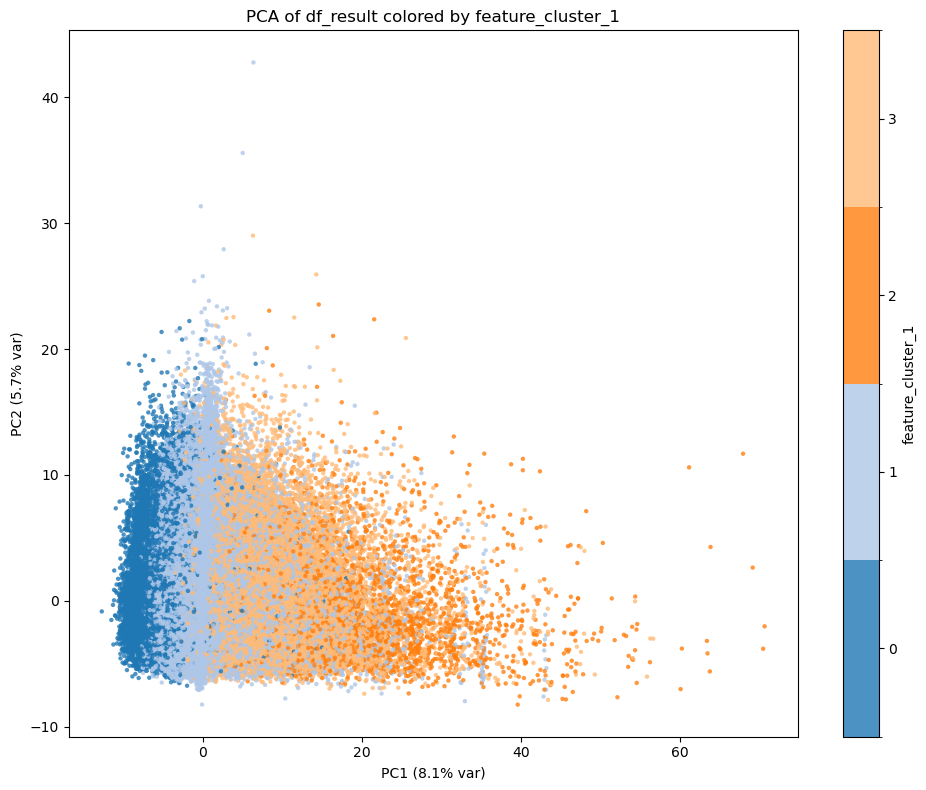

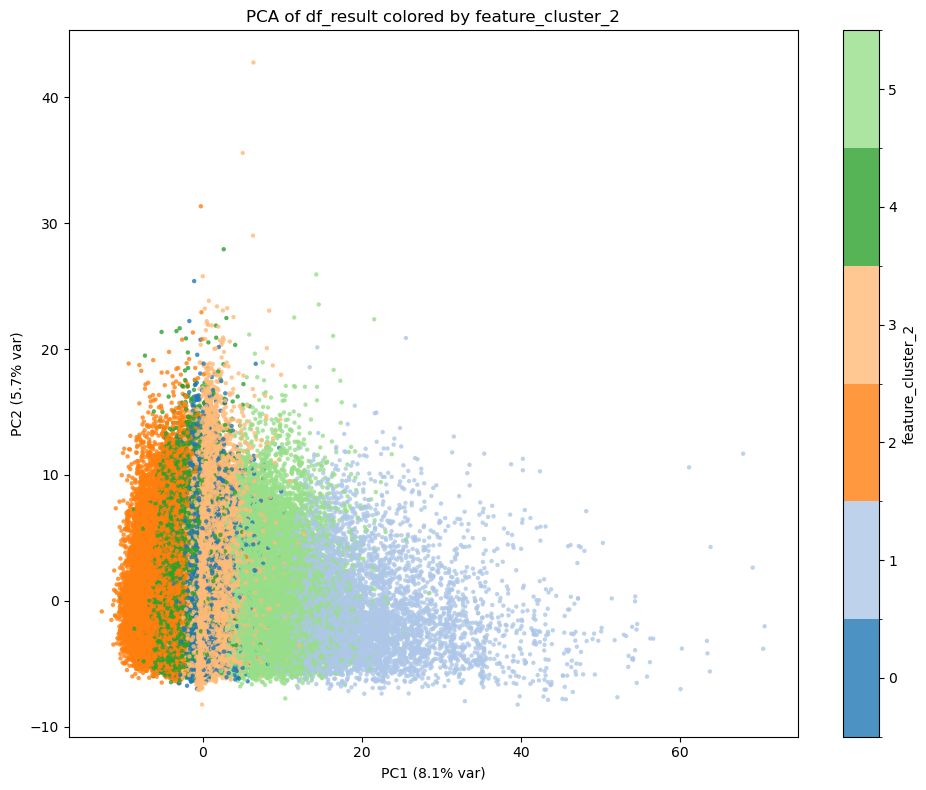

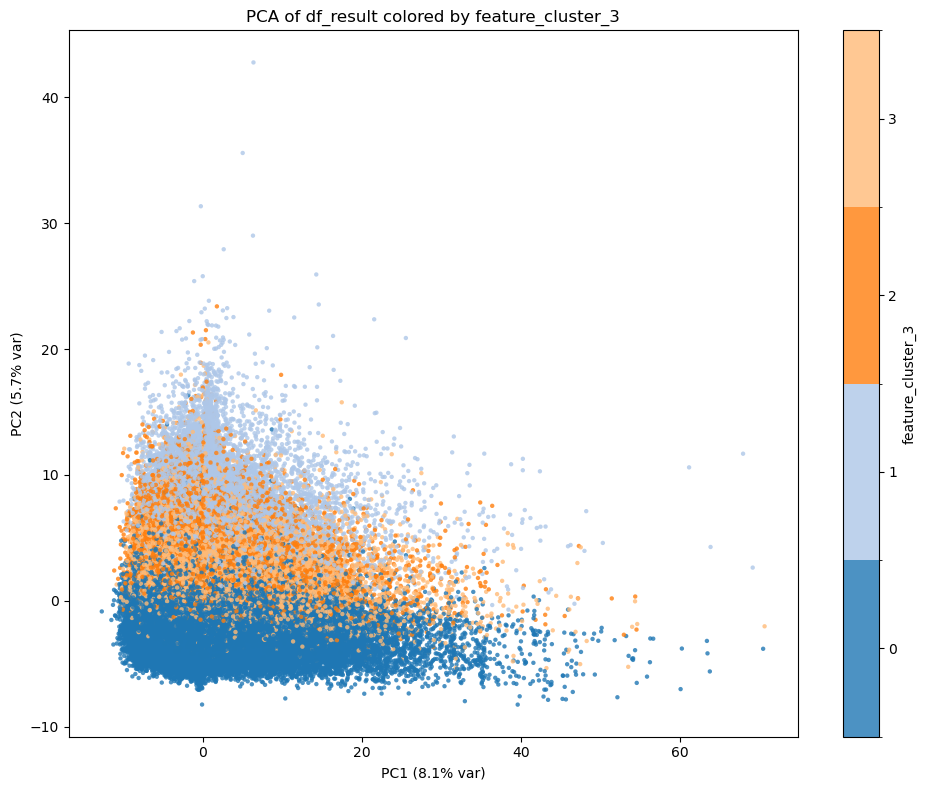

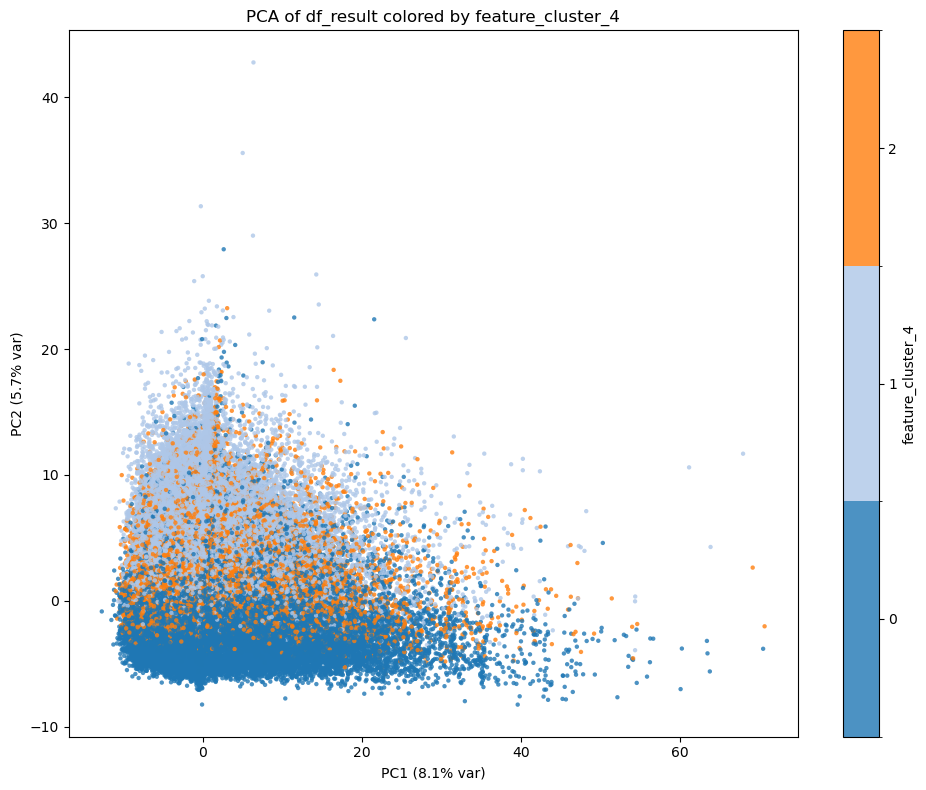

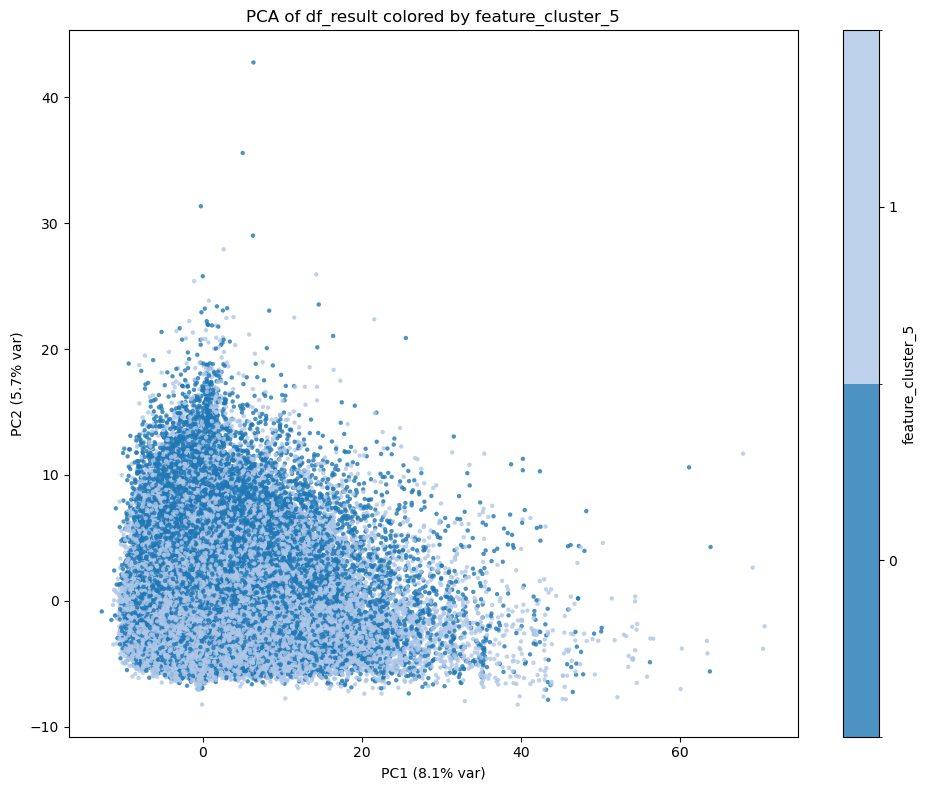

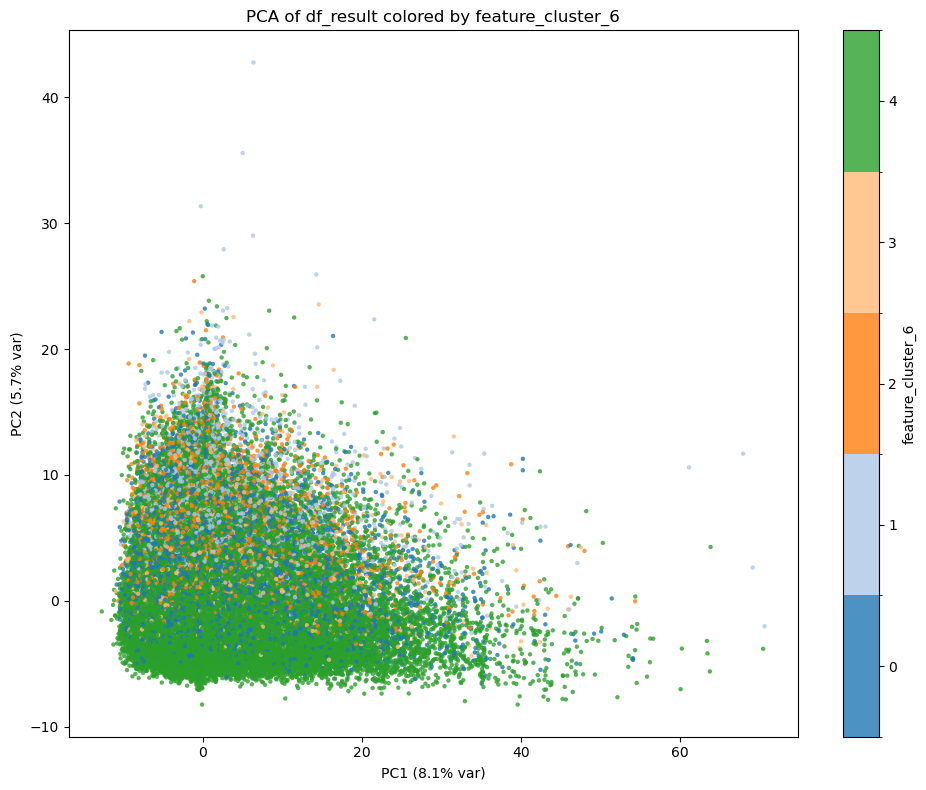

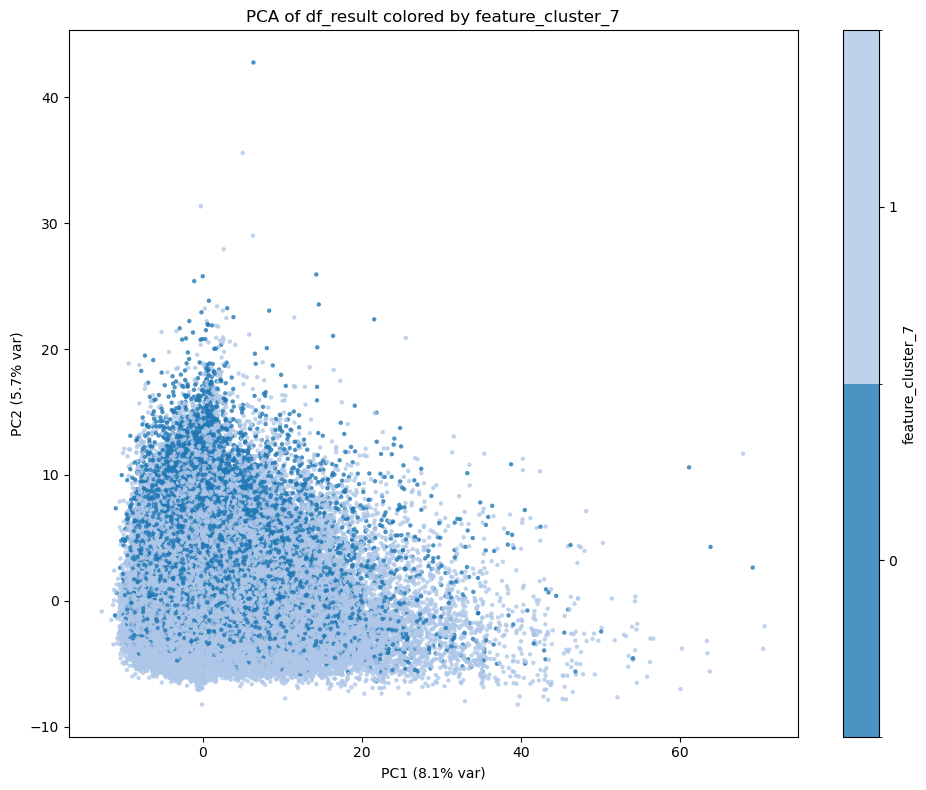

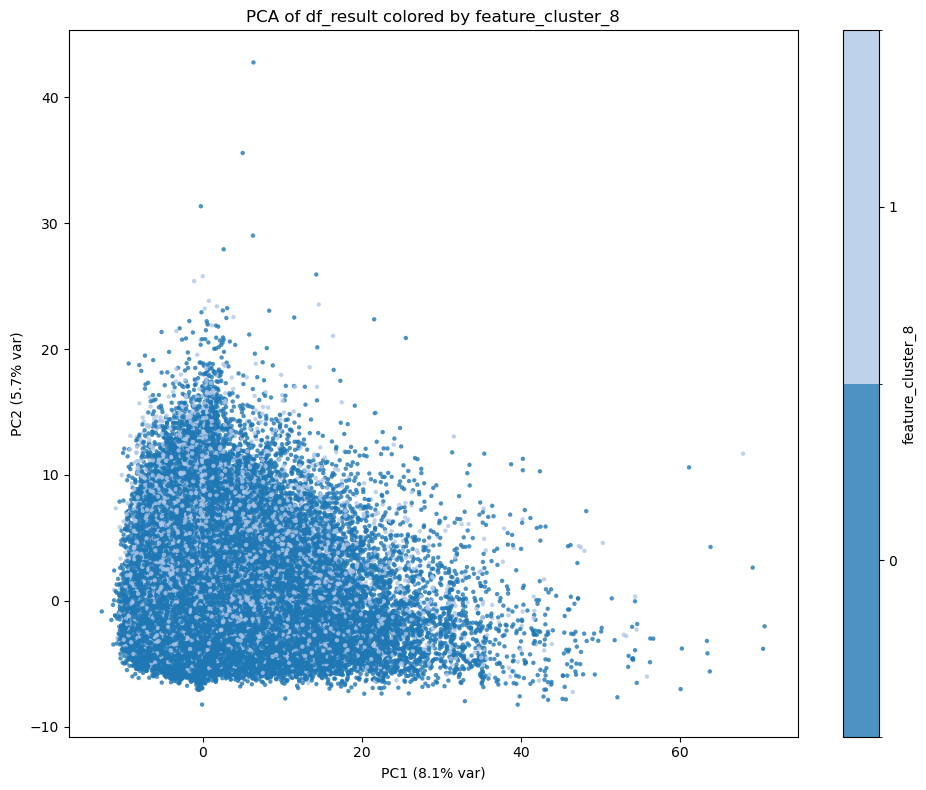

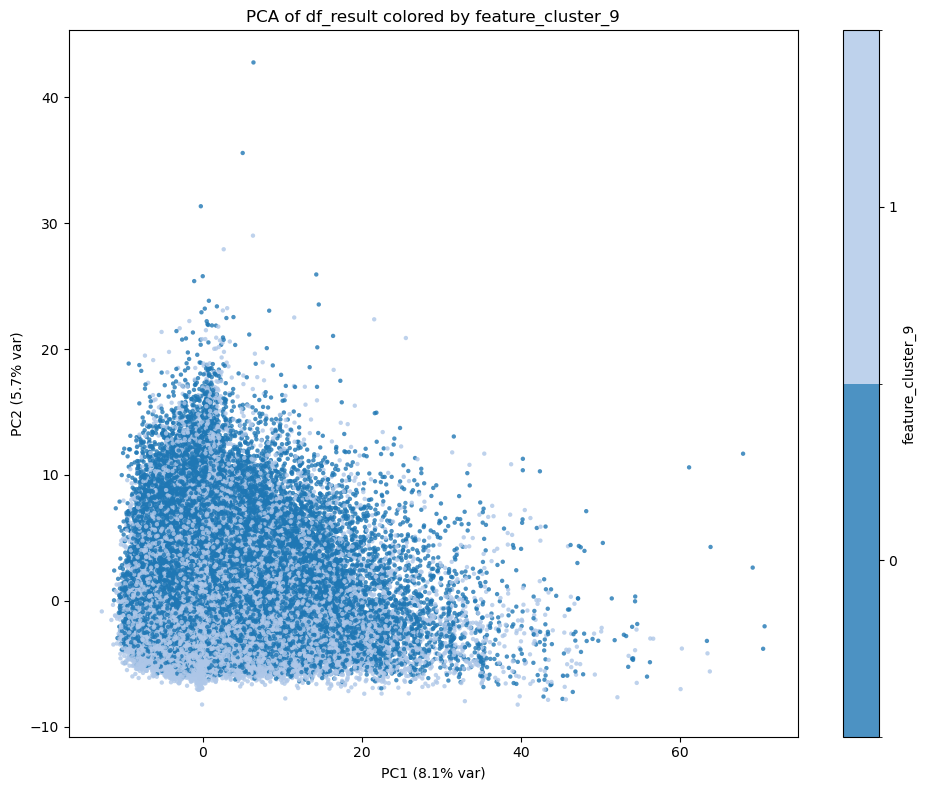

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np

# 1) 以 user 為 row、df_result 數值為輸入做 PCA
pca_input = (
    df_result
    .drop(columns=['SK_ID_CURR'], errors='ignore')
    .replace([np.inf, -np.inf], np.nan)
    .fillna(df_result.mean(numeric_only=True))
)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(StandardScaler().fit_transform(pca_input))

pca_frame = pd.DataFrame({
    'SK_ID_CURR': df_result['SK_ID_CURR'].values,
    'pc1': coords[:, 0],
    'pc2': coords[:, 1],
})

# 2) 找出所有 feature_cluster_* 欄位，逐一畫圖
cluster_cols = [c for c in labels_output.columns if c.startswith('feature_cluster_')]

for col in cluster_cols:
    plot_df = pca_frame.merge(labels_output[['SK_ID_CURR', col]], on='SK_ID_CURR', how='left')
    labels = plot_df[col].fillna(-1).astype(int).values
    unique_labels = np.unique(labels)
    norm = BoundaryNorm(
        boundaries=np.arange(unique_labels.min() - 0.5, unique_labels.max() + 1.5, 1),
        ncolors=len(unique_labels),
    )

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        plot_df['pc1'],
        plot_df['pc2'],
        c=labels,
        cmap='tab20',
        norm=norm,
        s=10,
        alpha=0.8,
        edgecolor='none',
    )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title(f"PCA of df_result colored by {col}")
    cbar = plt.colorbar(scatter, ticks=unique_labels)
    cbar.set_label(col)
    plt.tight_layout()
    plt.show()
